# Text Dataset EDA

Exploratory workflow for `data/articles.csv`. The goal is to understand document structure, text quality, and feature distributions before clustering or anomaly detection.

## Setup

In [1]:
from collections import Counter
from pathlib import Path
import re
import string
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start=None):
    """Find the project root from either the root folder or notebooks folder."""
    current = (start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / "data" / "articles.csv").exists():
            return path
    raise FileNotFoundError("Could not find data/articles.csv from the current working directory.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "articles.csv"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 180)
plt.style.use("default")

## Helper Functions

In [2]:
PUNCTUATION = set(string.punctuation)

STOPWORDS = {
    "a", "about", "above", "after", "again", "against", "all", "am", "an", "and", "any",
    "are", "as", "at", "be", "because", "been", "before", "being", "below", "between",
    "both", "but", "by", "can", "did", "do", "does", "doing", "down", "during", "each",
    "few", "for", "from", "further", "had", "has", "have", "having", "he", "her", "here",
    "hers", "herself", "him", "himself", "his", "how", "i", "if", "in", "into", "is", "it",
    "its", "itself", "just", "me", "more", "most", "my", "myself", "no", "nor", "not", "now",
    "of", "off", "on", "once", "only", "or", "other", "our", "ours", "ourselves", "out",
    "over", "own", "same", "she", "should", "so", "some", "such", "than", "that", "the",
    "their", "theirs", "them", "themselves", "then", "there", "these", "they", "this", "those",
    "through", "to", "too", "under", "until", "up", "very", "was", "we", "were", "what",
    "when", "where", "which", "while", "who", "whom", "why", "will", "with", "you", "your",
    "yours", "yourself", "yourselves"
}


def identify_columns(df: pd.DataFrame) -> tuple[str, str]:
    """Infer document ID and text columns using names, uniqueness, and text length."""
    columns_lower = {column.lower(): column for column in df.columns}

    id_candidates = ["doc_id", "document_id", "id", "article_id"]
    text_candidates = ["text", "content", "article", "body", "document"]

    doc_id_col = next((columns_lower[name] for name in id_candidates if name in columns_lower), None)
    text_col = next((columns_lower[name] for name in text_candidates if name in columns_lower), None)

    if doc_id_col is None:
        uniqueness = df.nunique(dropna=True).sort_values(ascending=False)
        doc_id_col = uniqueness.index[0]

    if text_col is None:
        object_columns = df.select_dtypes(include="object").columns
        if len(object_columns) == 0:
            raise ValueError("Could not infer a text column because there are no object columns.")
        avg_lengths = df[object_columns].fillna("").astype(str).map(len).mean().sort_values(ascending=False)
        text_col = avg_lengths.index[0]

    return doc_id_col, text_col


def safe_ratio(numerator: int, denominator: int) -> float:
    """Return a percentage ratio, protecting against empty text."""
    return 0.0 if denominator == 0 else 100.0 * numerator / denominator


def simple_tokenize(text: str) -> list[str]:
    """Tokenize text into lowercase word-like tokens for quick EDA."""
    return re.findall(r"[a-zA-Z]+(?:'[a-zA-Z]+)?", str(text).lower())


def compute_text_features(text: str) -> pd.Series:
    """Compute document-level text features useful for EDA and anomaly detection."""
    text = "" if pd.isna(text) else str(text)
    length = len(text)
    words = simple_tokenize(text)
    word_lengths = [len(word) for word in words]

    digit_count = sum(char.isdigit() for char in text)
    punctuation_count = sum(char in PUNCTUATION for char in text)
    uppercase_count = sum(char.isupper() for char in text)
    non_alpha_count = sum(not char.isalpha() for char in text)
    repeated_patterns = re.findall(r"(.)\1{3,}", text)

    return pd.Series(
        {
            "text_length": length,
            "word_count": len(words),
            "avg_word_length": float(np.mean(word_lengths)) if word_lengths else 0.0,
            "digit_ratio": safe_ratio(digit_count, length),
            "punctuation_ratio": safe_ratio(punctuation_count, length),
            "uppercase_ratio": safe_ratio(uppercase_count, length),
            "non_alpha_ratio": safe_ratio(non_alpha_count, length),
            "repeated_char_patterns": len(repeated_patterns),
        }
    )


def truncate_text(text: str, max_chars: int = 350) -> str:
    """Shorten long documents for readable notebook display."""
    text = "" if pd.isna(text) else str(text).replace("\n", " ")
    return text if len(text) <= max_chars else text[:max_chars].rstrip() + "..."


def plot_distribution(series: pd.Series, title: str, xlabel: str, filename: str, bins: int = 40) -> None:
    """Plot and save a single feature distribution."""
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(series.dropna(), bins=bins, color="#2f6f9f", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of documents")
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()


def show_extreme_documents(df: pd.DataFrame, sort_column: str, ascending: bool, title: str, n: int = 5) -> pd.DataFrame:
    """Display the top or bottom documents for an EDA feature."""
    display_columns = [doc_id_col, sort_column, "text_preview"]
    result = df.sort_values(sort_column, ascending=ascending).head(n)[display_columns]
    print(title)
    display(result)
    return result

## Load Dataset and Inspect Structure

In [3]:
df = pd.read_csv(DATA_PATH)
doc_id_col, text_col = identify_columns(df)

print(f"Dataset path: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")
print(f"Document ID column: {doc_id_col}")
print(f"Text column: {text_col}")
print("\nColumn names:")
print(list(df.columns))
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_values"))

df.head()

Dataset path: C:\Users\Admin\Storage\Akademik\Dersler\Erasmus Classes\Data Mining\Assignment3\data-mining-clustering-assignment\data\articles.csv
Dataset shape: (2164, 2)
Document ID column: doc_id
Text column: text

Column names:
['doc_id', 'text']

Missing values per column:


,missing_values
doc_id,0
text,0


,doc_id,text
0,DOC_00001,"When I first saw this, I thought for a second that it was a headline from The Star about the pliers found in the SRB recently. Y'know, sometimes they have wire-cutters built in..."
1,DOC_00002,The difficulties of a high Isp OTV include: Long transfer times (radiation damage from VanAllen belts for both the spacecraft and OTV Arcjets or Xenon thrusters require huge am...
2,DOC_00003,"Forwarded from Neal Ausman, Galileo Mission Director GALILEO MISSION DIRECTOR STATUS REPORT POST-LAUNCH April 9 - 15, 1993 SPACECRAFT 1. On April 9, real-time commands were sen..."
3,DOC_00004,Sjogren's syndrome has been known to induce dryness in vaginal tissue as well as induce primary biliary cirrhosis. Otherwise the abdominal swelling could be due to a complicati...
4,DOC_00005,"Yes, I want to concentrate on other development issues - I've created graphics libraries before, it's too time consuming... life's too short! Thanks for the clarification... Be..."


## Compute Text Features

In [4]:
feature_columns = [
    "text_length",
    "word_count",
    "avg_word_length",
    "digit_ratio",
    "punctuation_ratio",
    "uppercase_ratio",
    "non_alpha_ratio",
    "repeated_char_patterns",
]

text_features = df[text_col].apply(compute_text_features)
eda_df = pd.concat([df.copy(), text_features], axis=1)
eda_df["text_preview"] = eda_df[text_col].apply(truncate_text)

eda_df[[doc_id_col, *feature_columns, "text_preview"]].head()

,doc_id,text_length,word_count,avg_word_length,digit_ratio,punctuation_ratio,uppercase_ratio,non_alpha_ratio,repeated_char_patterns,text_preview
0,DOC_00001,408.0,56.0,4.214286,5.392157,23.284314,3.676471,42.401961,1.0,"When I first saw this, I thought for a second that it was a headline from The Star about the pliers found in the SRB recently. Y'know, sometimes they have wire-cutters built in..."
1,DOC_00002,1176.0,198.0,4.782828,0.000000,2.721088,2.891156,19.642857,0.0,The difficulties of a high Isp OTV include: Long transfer times (radiation damage from VanAllen belts for both the spacecraft and OTV Arcjets or Xenon thrusters require huge am...
2,DOC_00003,4186.0,613.0,5.143556,4.180602,4.777831,9.651218,24.677496,0.0,"Forwarded from Neal Ausman, Galileo Mission Director GALILEO MISSION DIRECTOR STATUS REPORT POST-LAUNCH April 9 - 15, 1993 SPACECRAFT 1. On April 9, real-time commands were sen..."
3,DOC_00004,458.0,70.0,5.414286,0.000000,3.930131,3.711790,18.122271,0.0,Sjogren's syndrome has been known to induce dryness in vaginal tissue as well as induce primary biliary cirrhosis. Otherwise the abdominal swelling could be due to a complicati...
4,DOC_00005,285.0,44.0,5.204545,0.350877,5.263158,2.807018,21.052632,0.0,"Yes, I want to concentrate on other development issues - I've created graphics libraries before, it's too time consuming... life's too short! Thanks for the clarification... Be..."


## Summary Statistics

In [5]:
summary_stats = eda_df[feature_columns].agg(["mean", "median", "min", "max"]).T
display(summary_stats)

,mean,median,min,max
text_length,886.481978,546.000000,201.000000,24514.000000
word_count,147.759704,94.000000,23.000000,2650.000000
avg_word_length,4.451542,4.417406,2.424176,6.500000
digit_ratio,1.305349,0.335009,0.000000,40.862364
punctuation_ratio,5.766011,4.037864,0.319375,54.915254
uppercase_ratio,4.627482,3.370155,0.000000,74.276860
non_alpha_ratio,24.132430,22.459635,16.097561,72.995023
repeated_char_patterns,0.321165,0.000000,0.000000,25.000000


## Feature Distributions

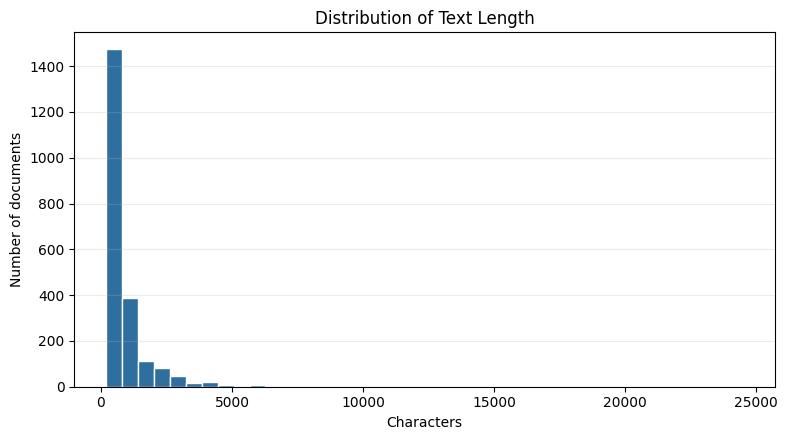

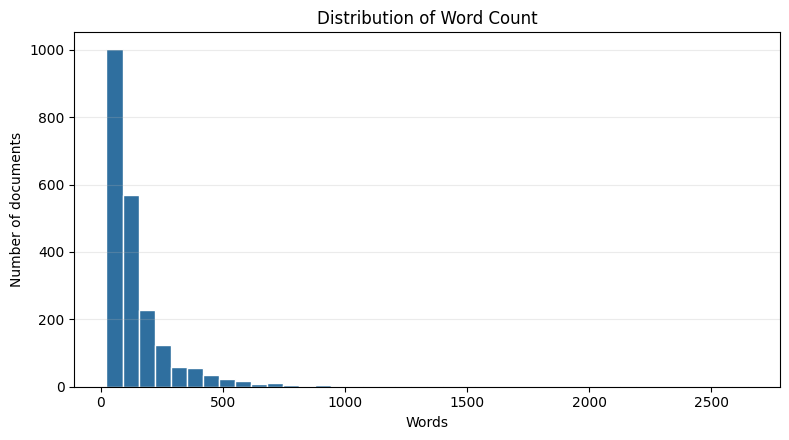

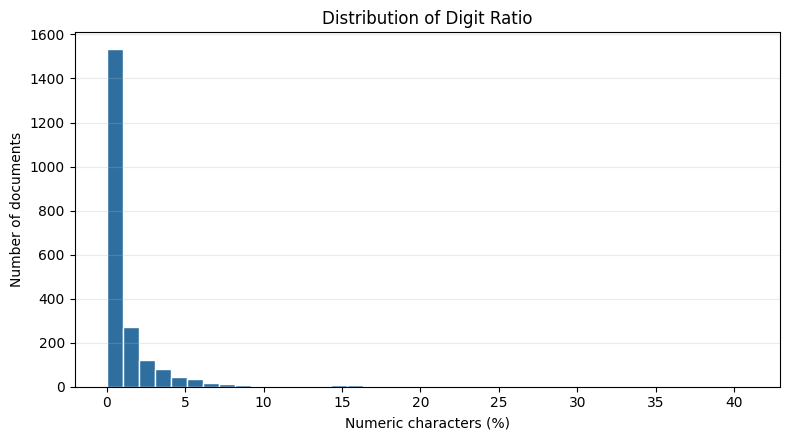

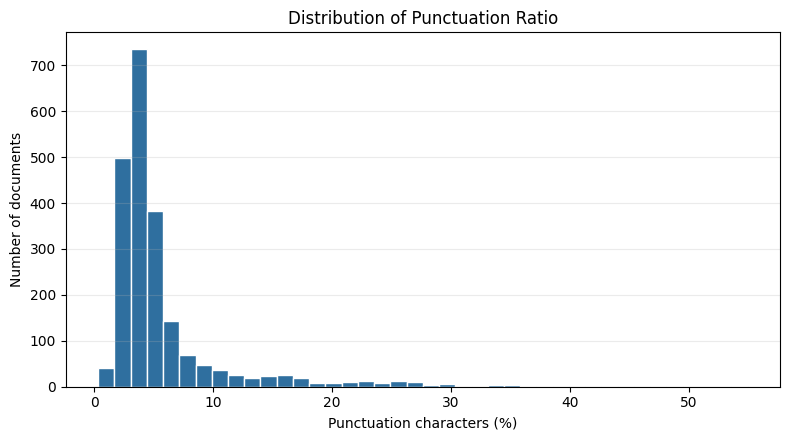

In [6]:
plot_distribution(eda_df["text_length"], "Distribution of Text Length", "Characters", "text_length_histogram.png")
plot_distribution(eda_df["word_count"], "Distribution of Word Count", "Words", "word_count_histogram.png")
plot_distribution(eda_df["digit_ratio"], "Distribution of Digit Ratio", "Numeric characters (%)", "digit_ratio_distribution.png")
plot_distribution(eda_df["punctuation_ratio"], "Distribution of Punctuation Ratio", "Punctuation characters (%)", "punctuation_ratio_distribution.png")

## Extreme Documents for Manual Review

In [7]:
shortest_documents = show_extreme_documents(eda_df, "text_length", True, "5 shortest documents")
longest_documents = show_extreme_documents(eda_df, "text_length", False, "5 longest documents")
highest_digit_ratio = show_extreme_documents(eda_df, "digit_ratio", False, "5 documents with highest digit ratio")
highest_punctuation_ratio = show_extreme_documents(eda_df, "punctuation_ratio", False, "5 documents with highest punctuation ratio")
most_repeated_characters = show_extreme_documents(eda_df, "repeated_char_patterns", False, "5 documents with most repeated character patterns")

5 shortest documents


,doc_id,text_length,text_preview
15,DOC_00016,201.0,"It would seem logical that the mask is Potvins. His nickname is ""The Cat"", which would go a long ways towards explaining the panther. Of course, it could be an old story and th..."
1087,DOC_01088,201.0,"Can anyone help me find any information on the drug Prozac? I am writing a report on the inventors , Eli Lilly and Co., and the product. I need as much help as I can get. Thank..."
1237,DOC_01238,201.0,"Why would you want to do that? The goal is to do it cheaper (remember, this isn't government). Instead of leasing an expensive launch pad, just use a SSTO and launch from a muc..."
199,DOC_00200,201.0,"Wow! A 68070! I'd be very interested to get my hands on one of these, especially considering the fact that Motorola has not yet released the 68060, which is supposedly the next..."
7,DOC_00008,201.0,"Assuming one has been cultured as having a throat laden with neiseria meningococcus and given (and taken) a course of ERYC without the culture becoming negative, should one wor..."


5 longest documents


,doc_id,text_length,text_preview
1715,DOC_01716,24514.0,Individual leaders by total points (Final standings) NOTE: Games played and points per games not accurate !! Player Team GP G A Pts ppg Prj PIM +/- M.Lemieux PIT 59 69 91 160 2...
1036,DOC_01037,15112.0,"The FLYERS blew a 3-0 lead over the Buffalo Sabres in the second period, but Kevin Dineen's 7th career hat trick powered them to their 7th consecutive win, 7-4 over the Sabres ..."
1876,DOC_01877,11956.0,"ETHER IMPLODES 2 EARTH CORE, IS GRAVITY!!! This paper BOTH describes how heavenly bodys can be stationary, ether sucking structures, AND why we observe ""orbital"" motion!! Ether..."
533,DOC_00534,11237.0,"Here are the standings after the April 6 update. I'll be leaving for Japan in 1.5 hours, and I won't be back until April 17. Consequently, I will not post the week 27 results u..."
1686,DOC_01687,11050.0,"Well, I'm back from Tokyo, so here are the standings after the April 13 update. - Andrew USENET Hockey Draft Standings Week 27 Posn Team Pts Proj Cash Last Posn 1. Dave Wessels..."


5 documents with highest digit ratio


,doc_id,digit_ratio,text_preview
1715,DOC_01716,40.862364,Individual leaders by total points (Final standings) NOTE: Games played and points per games not accurate !! Player Team GP G A Pts ppg Prj PIM +/- M.Lemieux PIT 59 69 91 160 2...
1686,DOC_01687,38.606335,"Well, I'm back from Tokyo, so here are the standings after the April 13 update. - Andrew USENET Hockey Draft Standings Week 27 Posn Team Pts Proj Cash Last Posn 1. Dave Wessels..."
533,DOC_00534,37.839281,"Here are the standings after the April 6 update. I'll be leaving for Japan in 1.5 hours, and I won't be back until April 17. Consequently, I will not post the week 27 results u..."
25,DOC_00026,35.502471,"I have the ""osculating elements at perigee"" of an orbit, which I need to convert to something useful, preferably distance from the earth in evenly spaced time intervals. A GSM ..."
177,DOC_00178,29.142857,FINAL 1992-93 AMERICAN HOCKEY LEAGUE STANDINGS NORTHERN DIVISION W L T PTS GF GA LYF* Providence Bruins 46 32 2 94 384 348 56 Adirondack Red Wings 36 35 9 81 331 308 84 Capital...


5 documents with highest punctuation ratio


,doc_id,punctuation_ratio,text_preview
1315,DOC_01316,54.915254,I'm looking for shading methods and algorithms. Please let me know if you know where to get source codes for that. Thanks a lot! Thomas +---------------------------------------...
374,DOC_00375,49.382716,"Also photoshopII is out soon, has anyone got a date and any cofmments? Andy _______________________________________________________ | Andrew Leahy | aleahy@cch.coventry.ac.uk |..."
116,DOC_00117,46.492271,"Hey Patrick, the Montana Magic played in Billings, not Great Falls... Marc, Phoenix and Houston it is... -----------------------------------------------------------------------..."
1102,DOC_01103,44.327177,"HI All, Can someone point me towards some articles on 'boids' or flocking algorithms... ? Also, articles on particle animation formulas would be nice... _______________________..."
476,DOC_00477,42.105263,"See: Maureen Stone and Tony DeRose, ""A Geometric Characterization of Parametric Cubic Curves"", ACM TOG, vol 8, no 3, July 1989, pp. 147-163. ___________________________________..."


5 documents with most repeated character patterns


,doc_id,repeated_char_patterns,text_preview
1760,DOC_01761,25.0,"I'm working upon a game using an isometric perspective, similar to that used in Populous. Basically, you look into a room that looks similar to the following: xxxx xxxxx xxxx x..."
1950,DOC_01951,19.0,"ARIANESPACE FLIGHT 56 (Flight V.56 was originally intended to carry the Hughes HS-601 series Galaxy IV satellite, but the payload was withdrawn just prior to flight.) The 56th ..."
315,DOC_00316,13.0,"""Deeply rooted rivalry?"" Ahem, Jokerit have been around since 1967 and joined the top flight only in the early '70s. Helsingfors IFK have been around since 1897 but fans only s..."
341,DOC_00342,9.0,@>> @>>Has anyone had any experience with GEICO's extended @>>warranty plan. It seems to be slightly less expensive than @>>the normal dealer-sponsored policy. @>> @>and once a...
25,DOC_00026,8.0,"I have the ""osculating elements at perigee"" of an orbit, which I need to convert to something useful, preferably distance from the earth in evenly spaced time intervals. A GSM ..."


## Sample Texts for Inspection

In [8]:
sample_texts = eda_df.sample(n=min(10, len(eda_df)), random_state=42)[
    [doc_id_col, "text_length", "word_count", "digit_ratio", "punctuation_ratio", "text_preview"]
]
display(sample_texts)

,doc_id,text_length,word_count,digit_ratio,punctuation_ratio,text_preview
2076,DOC_02077,2818.0,249.0,25.124202,0.319375,"Playoff leaders as of April 19, 1993 Player Team GP G A Pts +/- PIM M.Lemieux PIT 1 2 2 4 0 0 Juneau BOS 1 1 3 4 0 0 Noonan CHI 1 3 0 3 0 0 Mogilny BUF 1 2 1 3 0 0 Neely BOS 1 ..."
1601,DOC_01602,3396.0,601.0,0.323910,3.239105,"(excerpts from posting on this topic) (I've seen satellites at midnight - they're not only in twilight.) :o) Now my comments: I'd like to add that some of the ""protests"" do not..."
1431,DOC_01432,2712.0,430.0,0.000000,3.576696,someone wrote in expressing concern about getting AIDS from acupuncture needles..... Unless your friend is sharing fluids with their acupuncturist who themselves has AIDS..it i...
1134,DOC_01135,401.0,59.0,0.249377,23.940150,"Try peeling the skin back at the base of your other fingernails (not too hard, now, don't want to hurt yourself). You'll find nice little lunulas there if you can peel it back ..."
1512,DOC_01513,970.0,162.0,0.206186,6.597938,"True, coach Matikainen is ready to keep a spot for Teemu all the way until the medal games. He wants Teppo Numminen, too. And Kurri, but for them the spots cannot be left open ..."
1786,DOC_01787,633.0,126.0,0.000000,2.527646,"I'll probably get flamed for this, but when I was a kid we would go to my uncles cabin on Middle Bass Island on Lake Erie. We always came home with a nasty case of jiggers (lar..."
478,DOC_00479,987.0,148.0,4.052685,7.396150,"Everybody. Please send me your predictions for the Stanley Cup Playoffs! I want to see who people think will win.!!!!!!! Please Send them in this format, or something comparabl..."
1001,DOC_01002,267.0,46.0,0.749064,2.247191,Several company publish periodicals (3 or 4 times a year) which list the sticker prices and the dealer invoice prices of all the cars and their options. Edmund's is the name of...
2026,DOC_02027,327.0,51.0,0.000000,11.620795,"Hmmmm.... The prefix ""peri-"" is Greek, not Latin, so it's usually used with the Greek form of the name of the body being orbited. (That's why it's ""perihelion"" rather than ""per..."
1745,DOC_01746,633.0,103.0,10.110585,9.004739,Help! I'm trying to program my VGA! I've got it working with in pascal with the following routines for mode $13h (320*200*256). I've got a VESA compatable Trident 8900C w/1meg ...


## Most Frequent Words

,word,count
0,would,1151
1,offer,1146
2,pickup,895
3,deal,884
4,one,856
5,like,761
6,fast,760
7,bonus,660
8,sale,655
9,get,654


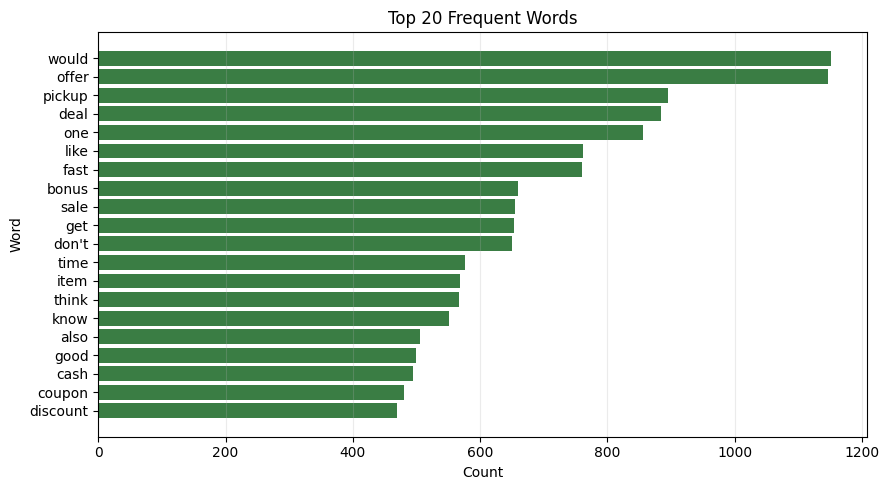

In [9]:
tokens = []
for text in eda_df[text_col].fillna(""):
    tokens.extend(token for token in simple_tokenize(text) if token not in STOPWORDS and len(token) > 1)

top_words = pd.DataFrame(Counter(tokens).most_common(20), columns=["word", "count"])
display(top_words)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_words["word"][::-1], top_words["count"][::-1], color="#3a7d44")
ax.set_title("Top 20 Frequent Words")
ax.set_xlabel("Count")
ax.set_ylabel("Word")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "top_20_words.png", dpi=150, bbox_inches="tight")
plt.show()

## EDA Notes for Next Steps

In [10]:
notes = {
    "documents": len(eda_df),
    "median_text_length": eda_df["text_length"].median(),
    "max_text_length": eda_df["text_length"].max(),
    "median_word_count": eda_df["word_count"].median(),
    "max_word_count": eda_df["word_count"].max(),
    "documents_with_digits_pct": 100 * (eda_df["digit_ratio"] > 0).mean(),
    "documents_with_repeated_characters_pct": 100 * (eda_df["repeated_char_patterns"] > 0).mean(),
}

print("Key EDA signals:")
for key, value in notes.items():
    print(f"- {key}: {value:.2f}" if isinstance(value, float) else f"- {key}: {value}")

print("\nHow to use these signals:")
print("- Very short or very long documents may need special handling before clustering.")
print("- High digit, punctuation, uppercase, or non-alphabetic ratios are useful anomaly features.")
print("- Frequent words help decide stopword additions and domain-specific preprocessing rules.")
print("- Wide length variation can strongly affect vectorization and distance-based clustering.")

Key EDA signals:
- documents: 2164
- median_text_length: 546.00
- max_text_length: 24514.00
- median_word_count: 94.00
- max_word_count: 2650.00
- documents_with_digits_pct: 62.80
- documents_with_repeated_characters_pct: 19.04

How to use these signals:
- Very short or very long documents may need special handling before clustering.
- High digit, punctuation, uppercase, or non-alphabetic ratios are useful anomaly features.
- Frequent words help decide stopword additions and domain-specific preprocessing rules.
- Wide length variation can strongly affect vectorization and distance-based clustering.


## Clustering Experiments

In [11]:
from src.preprocessing import build_tfidf_features
from src.clustering import (
    evaluate_labels,
    find_representative_documents,
    get_cluster_labels,
    get_top_terms_per_cluster,
    run_agglomerative,
    run_kmeans,
)

documents = eda_df[text_col].fillna("").tolist()
tfidf_matrix, tfidf_vectorizer = build_tfidf_features(
    documents,
    max_features=3000,
    min_df=2,
)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (2164, 3000)


In [12]:
experiment_rows = []
fitted_models = {}
cluster_labels_by_model = {}

for k in range(2, 11):
    kmeans_model = run_kmeans(tfidf_matrix, n_clusters=k, random_state=42)
    kmeans_labels = get_cluster_labels(kmeans_model)
    kmeans_score = evaluate_labels(tfidf_matrix, kmeans_labels)

    experiment_rows.append(
        {"method": "K-Means", "k": k, "silhouette_score": kmeans_score}
    )
    fitted_models[("K-Means", k)] = kmeans_model
    cluster_labels_by_model[("K-Means", k)] = kmeans_labels

    agglomerative_model = run_agglomerative(tfidf_matrix, n_clusters=k)
    agglomerative_labels = get_cluster_labels(agglomerative_model)
    agglomerative_score = evaluate_labels(tfidf_matrix, agglomerative_labels)

    experiment_rows.append(
        {"method": "Agglomerative", "k": k, "silhouette_score": agglomerative_score}
    )
    fitted_models[("Agglomerative", k)] = agglomerative_model
    cluster_labels_by_model[("Agglomerative", k)] = agglomerative_labels

clustering_results = pd.DataFrame(experiment_rows)
comparison_table = clustering_results.pivot(
    index="k",
    columns="method",
    values="silhouette_score",
).round(4)

display(comparison_table)
display(clustering_results.sort_values("silhouette_score", ascending=False).reset_index(drop=True))

method,Agglomerative,K-Means
k,,
2,0.0086,0.0093
3,0.0116,0.0098
4,0.0128,0.0109
5,0.0132,0.0125
6,0.0133,0.0131
7,0.0143,0.0168
8,0.0151,0.0161
9,0.0161,0.0162
10,0.0161,0.0164


,method,k,silhouette_score
0,K-Means,7,0.016808
1,K-Means,10,0.016411
2,K-Means,9,0.016186
3,K-Means,8,0.016109
4,Agglomerative,9,0.016060
5,Agglomerative,10,0.016051
6,Agglomerative,8,0.015109
7,Agglomerative,7,0.014313
8,Agglomerative,6,0.013252
9,Agglomerative,5,0.013213


## Qualitative Inspection of Best K-Means Model

In [13]:
best_kmeans_row = clustering_results[clustering_results["method"] == "K-Means"].sort_values(
    "silhouette_score",
    ascending=False,
).iloc[0]

best_k = int(best_kmeans_row["k"])
best_kmeans_model = fitted_models[("K-Means", best_k)]
best_kmeans_labels = cluster_labels_by_model[("K-Means", best_k)]

print(f"Best K-Means k by silhouette score: {best_k}")
print(f"Silhouette score: {best_kmeans_row['silhouette_score']:.4f}")

top_terms = get_top_terms_per_cluster(best_kmeans_model, tfidf_vectorizer, top_n=10)
top_terms_table = pd.DataFrame(
    [
        {"cluster": cluster_id, "top_terms": ", ".join(terms)}
        for cluster_id, terms in top_terms.items()
    ]
)
display(top_terms_table)

Best K-Means k by silhouette score: 7
Silhouette score: 0.0168


,cluster,top_terms
0,0,"gebcadredslpittedu, shameful, chastity, n3jxp, surrender, skepticism, intellect, banks, gordon, soon"
1,1,"dont, like, just, people, think, know, msg, time, good, im"
2,2,"space, moon, orbit, launch, lunar, like, nasa, earth, just, station"
3,3,"thanks, graphics, files, program, know, help, does, looking, file, im"
4,4,"car, cars, engine, just, dealer, like, price, ford, good, dont"
5,5,"game, team, hockey, players, games, play, season, teams, nhl, think"
6,6,"pickup, bonus, offer, deal, fast, sale, cash, item, listing, discount"


In [14]:
representatives = find_representative_documents(
    tfidf_matrix,
    best_kmeans_labels,
    document_ids=eda_df[doc_id_col].to_numpy(),
    top_n=3,
)

representative_rows = []
for cluster_id, document_ids in representatives.items():
    for document_id in document_ids:
        row = eda_df.loc[eda_df[doc_id_col] == document_id].iloc[0]
        representative_rows.append(
            {
                "cluster": cluster_id,
                doc_id_col: document_id,
                "text_length": row["text_length"],
                "word_count": row["word_count"],
                "text_preview": row["text_preview"],
            }
        )

representative_documents = pd.DataFrame(representative_rows)
display(representative_documents)

,cluster,doc_id,text_length,word_count,text_preview
0,0,DOC_01195,270.0,34.0,"Senile keratoses. Have nothing to do with the liver. -- ---------------------------------------------------------------------------- Gordon Banks N3JXP | ""Skepticism is the cha..."
1,0,DOC_00512,256.0,34.0,"So just what was it you wanted to say? -- ---------------------------------------------------------------------------- Gordon Banks N3JXP | ""Skepticism is the chastity of the i..."
2,0,DOC_00189,341.0,45.0,It can suppress secretion of prolactin. Is useful in cases of galactorrhea. Some adenomas of the pituitary secret too much. -- -------------------------------------------------...
3,1,DOC_01430,1321.0,237.0,Hmmm. The last time I got stung by a bee I experienced the same reaction the first poster's brother did. We went off to the doctor to see if I should worry about the fact that ...
4,1,DOC_00204,2822.0,499.0,"I may not be the world's greatest expert on chiggers (a type of mite indigenous to the south), but I certainly have spent a lot of time contemplating the little buggers over th..."
5,1,DOC_01371,4172.0,795.0,"Hi, I've just returned from a visit with my OB/GYN and I have a few concerns that maybe y'all can help me with. I've been seeing her every 4 weeks for the past few months (I'm ..."
6,2,DOC_01351,3561.0,564.0,"There is an interesting opinion piece in the business section of today's LA Times (Thursday April 15, 1993, p. D1). I thought I'd post it to stir up some flame wars - I mean re..."
7,2,DOC_01059,678.0,124.0,"Re: Space billboards Even easier to implement than writing messages on the Moon, once upon a time a group of space activists I belonged to in Seattle considered a ""Goodyear Bli..."
8,2,DOC_00814,4488.0,707.0,SSF is up for redesign again. Let's do it right this time! Let's step back and consider the functionality we want: [1] microgravity/vacuum process research [2] life sciences re...
9,3,DOC_00357,464.0,88.0,"Howdy all, I was wondering if people could e-mail me their opinions on the various graphics viewers available for MS-Windows 3.x... I'm working on a project to set up our scann..."


## K-Means k=7 Cluster Balance Diagnostics

In [15]:
selected_k = 7
selected_labels = cluster_labels_by_model[("K-Means", selected_k)]

cluster_balance = (
    pd.Series(selected_labels, name="cluster")
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="document_count")
)
cluster_balance["document_percentage"] = (
    100 * cluster_balance["document_count"] / len(selected_labels)
).round(2)

print(f"K-Means k={selected_k} cluster balance")
display(cluster_balance)

K-Means k=7 cluster balance


,cluster,document_count,document_percentage
0,0,69,3.19
1,1,830,38.35
2,2,227,10.49
3,3,374,17.28
4,4,263,12.15
5,5,367,16.96
6,6,34,1.57


## Final clusters.csv Verification

In [16]:
articles_check = pd.read_csv(DATA_PATH)
clusters_check = pd.read_csv(PROJECT_ROOT / "data" / "clusters.csv")

verification = {
    "row_count_matches": len(clusters_check) == len(articles_check),
    "doc_id_order_matches": clusters_check[doc_id_col].tolist() == articles_check[doc_id_col].tolist(),
    "cluster_labels_are_integers": pd.api.types.is_integer_dtype(clusters_check["label"]),
    "unique_cluster_count_is_7": clusters_check["label"].nunique() == 7,
}

for check, passed in verification.items():
    print(f"{check}: {passed}")

display(
    clusters_check["label"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="document_count")
)

row_count_matches: True
doc_id_order_matches: True
cluster_labels_are_integers: True
unique_cluster_count_is_7: True


,cluster,document_count
0,0,69
1,1,830
2,2,227
3,3,374
4,4,263
5,5,367
6,6,34


## Anomaly Detection

In [17]:
from src.anomaly_detection import (
    build_anomaly_feature_matrix,
    combine_weighted_scores,
    compute_listing_pattern_score,
    compute_structural_features,
    get_anomaly_scores,
    get_lof_scores,
    reduce_tfidf_features,
    run_isolation_forest,
    run_local_outlier_factor,
    select_top_anomalies,
)

articles_for_anomalies = pd.read_csv(DATA_PATH)
anomaly_template = pd.read_csv(PROJECT_ROOT / "data" / "anomalies.csv")
anomaly_documents = articles_for_anomalies[text_col].fillna("").tolist()

anomaly_structural_features = compute_structural_features(anomaly_documents)
anomaly_tfidf_matrix, anomaly_vectorizer = build_tfidf_features(
    anomaly_documents,
    max_features=3000,
    min_df=2,
)
anomaly_reduced_tfidf, anomaly_svd = reduce_tfidf_features(
    anomaly_tfidf_matrix,
    n_components=50,
    random_state=42,
)
anomaly_features, anomaly_scaler = build_anomaly_feature_matrix(
    anomaly_structural_features,
    anomaly_reduced_tfidf,
)

anomaly_contamination = 50 / len(articles_for_anomalies)
isolation_forest_model = run_isolation_forest(
    anomaly_features,
    contamination=anomaly_contamination,
    random_state=42,
)
lof_model = run_local_outlier_factor(
    anomaly_features,
    n_neighbors=35,
    contamination=anomaly_contamination,
)

isolation_scores = get_anomaly_scores(isolation_forest_model, anomaly_features)
lof_scores = get_lof_scores(lof_model)
listing_pattern_scores = compute_listing_pattern_score(anomaly_structural_features)
combined_scores = combine_weighted_scores(
    [isolation_scores, lof_scores, listing_pattern_scores],
    weights=[0.15, 0.15, 0.70],
)

top_anomalies = select_top_anomalies(
    articles_for_anomalies[doc_id_col].to_numpy(),
    combined_scores,
    n_anomalies=50,
)

completed_anomalies = anomaly_template.copy()
completed_anomalies["doc_id"] = top_anomalies["doc_id"].to_numpy()
completed_anomalies.to_csv(PROJECT_ROOT / "data" / "anomalies.csv", index=False)

print("Saved data/anomalies.csv with exactly 50 selected document IDs.")

Saved data/anomalies.csv with exactly 50 selected document IDs.


In [18]:
anomaly_scores_df = pd.DataFrame(
    {
        doc_id_col: articles_for_anomalies[doc_id_col],
        "isolation_forest_score": isolation_scores,
        "lof_score": lof_scores,
    }
)

anomaly_review = (
    top_anomalies.merge(anomaly_scores_df, on=doc_id_col, how="left")
    .merge(
        pd.concat(
            [articles_for_anomalies[[doc_id_col, text_col]], anomaly_structural_features],
            axis=1,
        ),
        on=doc_id_col,
        how="left",
    )
)
anomaly_review["text_preview"] = anomaly_review[text_col].apply(truncate_text)

listing_or_sale_mask = (
    anomaly_review["listing_keyword_count"]
    + anomaly_review["sale_keyword_count"]
    + anomaly_review["commercial_phrase_count"]
) > 0

print("Selected anomalies containing LISTING_ID:", int(anomaly_review["contains_listing_id"].sum()))
print("Selected anomalies containing listing/sale keywords:", int(listing_or_sale_mask.sum()))

display_columns = [
    doc_id_col,
    "combined_anomaly_score",
    "contains_listing_id",
    "listing_keyword_count",
    "sale_keyword_count",
    "commercial_phrase_count",
    "text_length",
    "word_count",
    "avg_word_length",
    "digit_ratio",
    "punctuation_ratio",
    "uppercase_ratio",
    "non_alpha_ratio",
    "repeated_char_count",
    "text_preview",
]

display(anomaly_review[display_columns].head(20))

Selected anomalies containing LISTING_ID: 50
Selected anomalies containing listing/sale keywords: 50


,doc_id,combined_anomaly_score,contains_listing_id,listing_keyword_count,sale_keyword_count,commercial_phrase_count,text_length,word_count,avg_word_length,digit_ratio,punctuation_ratio,uppercase_ratio,non_alpha_ratio,repeated_char_count,text_preview
0,DOC_00390,0.839955,1,101,210,35,3602,548,5.235401,1.804553,3.914492,21.432537,20.349806,0,"LISTING_ID_042 For sale: used chair, pickup in Hasselt, asking price 300 euro. selling because of upgrade. recently cleaned. selling because of upgrade. available immediately. ..."
1,DOC_01208,0.723568,1,58,200,32,3239,504,5.125000,1.173202,3.766595,20.994134,20.253165,0,"LISTING_ID_020 Second-hand car, refurbished, collection in Brussels, around 600 euro. selling because of upgrade. serious offers only. kept in good shape. battery included. bat..."
2,DOC_01470,0.712211,1,56,231,18,2899,505,4.615842,2.311142,1.828217,22.387030,19.592963,0,"LISTING_ID_005 Second-hand laptop, good condition, collection in Hasselt, around 75 euro. kept in good shape. selling because of upgrade. original packaging not included. minor..."
3,DOC_00105,0.689122,1,81,124,48,2531,400,4.890000,1.540893,5.333860,25.088898,22.718293,0,"LISTING_ID_033 Selling my sofa, used, located near Hasselt, price 1200 EUR. cash on pickup. well maintained. well maintained. selling because of upgrade. Contact: usedgoods.rep..."
4,DOC_01743,0.668413,1,57,165,36,2336,372,4.908602,2.226027,4.494863,18.964041,21.832192,0,"LISTING_ID_028 Selling my chair, clean, located near Brussels, price 850 EUR. recently cleaned. no major defects. kept in good shape. well maintained. well maintained. Contact:..."
5,DOC_00341,0.640870,1,49,199,18,2296,378,4.976190,0.740418,0.827526,16.724739,18.074913,0,"LISTING_ID_024 For sale: well maintained guitar, pickup in Leuven, asking price 150 euro. can be tested on site. recently cleaned. works perfectly. kept in good shape. no major..."
6,DOC_02140,0.634201,1,65,141,36,2914,442,5.237557,0.583391,3.740563,22.649279,20.555937,0,"LISTING_ID_044 Printer for sale, good condition, available in Leuven, asking 150. pickup preferred. original packaging not included. battery included. battery included. recentl..."
7,DOC_01808,0.601847,1,28,238,4,2863,435,5.202299,2.060775,4.400978,26.405868,20.957038,0,"LISTING_ID_036 Second-hand guitar, almost new, collection in Liege, around 120 euro. can be tested on site. selling because of upgrade. original packaging not included. pickup ..."
8,DOC_00501,0.591338,1,68,95,43,2245,357,4.896359,2.449889,4.944321,27.928731,22.138085,0,"LISTING_ID_022 Second-hand sofa, refurbished, collection in Leuven, around 600 euro. stored indoors. cash on pickup. minor signs of use. serious offers only. Contact: fastdeal...."
9,DOC_00642,0.580561,1,89,161,4,2509,423,4.817967,2.072539,1.833400,29.573535,18.772419,0,"LISTING_ID_046 Selling my camera, excellent, located near Antwerp, price 250 EUR. kept in good shape. minor signs of use. pickup preferred. original packaging not included. wor..."


In [19]:
clusters_path = PROJECT_ROOT / "data" / "clusters.csv"
if clusters_path.exists():
    final_clusters = pd.read_csv(clusters_path)
    anomaly_cluster_counts = (
        completed_anomalies.merge(final_clusters, on=doc_id_col, how="left")
        ["label"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("cluster_label")
        .reset_index(name="selected_anomaly_count")
    )
    display(anomaly_cluster_counts)
else:
    print("clusters.csv was not found; skipping anomaly counts by cluster.")

,cluster_label,selected_anomaly_count
0,1,15
1,4,1
2,6,34


## Final anomalies.csv Verification

In [20]:
saved_anomalies = pd.read_csv(PROJECT_ROOT / "data" / "anomalies.csv")

anomaly_verification = {
    "contains_exactly_50_rows": len(saved_anomalies) == 50,
    "all_ids_exist_in_articles": saved_anomalies[doc_id_col].isin(articles_for_anomalies[doc_id_col]).all(),
    "has_no_duplicate_ids": not saved_anomalies[doc_id_col].duplicated().any(),
    "format_matches_template": list(saved_anomalies.columns) == list(anomaly_template.columns),
    "has_no_unnamed_index_column": not any(column.startswith("Unnamed") for column in saved_anomalies.columns),
}

for check, passed in anomaly_verification.items():
    print(f"{check}: {passed}")

contains_exactly_50_rows: True
all_ids_exist_in_articles: True
has_no_duplicate_ids: True
format_matches_template: True
has_no_unnamed_index_column: True
